#Dependencias


In [ ]:
import pandas as pd
import kagglehub
import os
import matplotlib.pyplot as plt

path = kagglehub.dataset_download("bishals098/nasa-turbofan-engine-degradation-simulation")
engine_data = pd.read_csv(os.path.join(path, "train_FD001.txt"), sep=r"\s+", header=None)
engine_altitud_change = pd.read_csv(os.path.join(path, "train_FD002.txt"), sep=r"\s+", header=None)

sensor_names = [
    "T2",
    "T24",
    "T30",
    "T50",
    "P2",
    "P15",
    "P30",
    "Nf",
    "Nc",
    "epr",
    "Ps30",
    "phi",
    "NRf",
    "NRc",
    "BPR",
    "farB",
    "htBleed",
    "Nf_dmd",
    "PCNfR_dmd",
    "W31",
    "W32"
]

column_names = [
    "motor_id",
    "ciclo",
    "configuracion_1",
    "configuracion_2",
    "configuracion_3"
] + sensor_names


engine_data.columns = column_names
engine_altitud_change.columns = column_names
engine_data_limpio = engine_data.drop(["configuracion_1","configuracion_2","configuracion_3"], axis=1)



Using Colab cache for faster access to the 'nasa-turbofan-engine-degradation-simulation' dataset.


#¿Los cambios atípicos aparecen aislados o se concentran en determinadas etapas de la vida del motor?

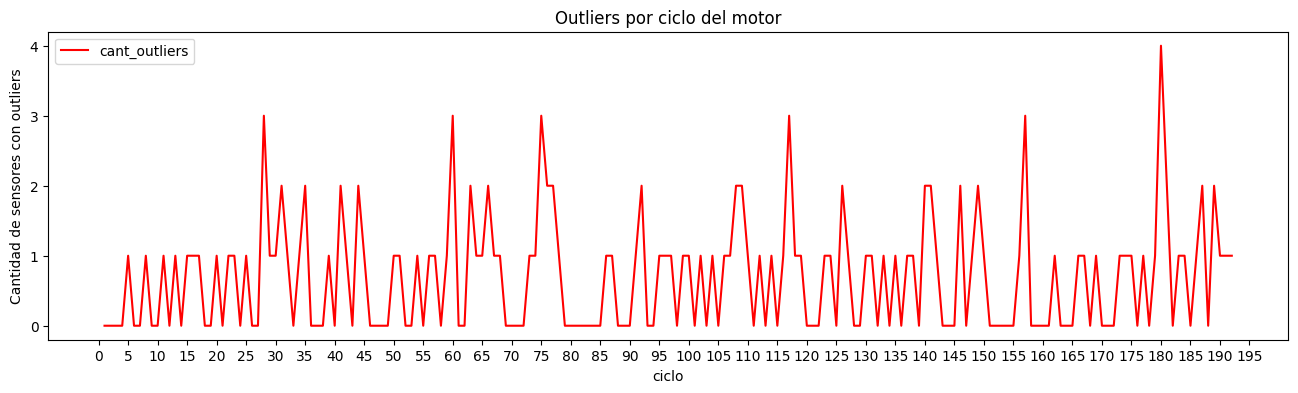

In [ ]:

df_motor_1 = engine_data_limpio[engine_data_limpio["motor_id"] == 1]
df_cambios = pd.DataFrame()

for sensor in df_motor_1.columns:
  if sensor in ["motor_id","ciclo"]:
    df_cambios[sensor] = df_motor_1[sensor]
    continue

  df_cambios[sensor] = df_motor_1[sensor].diff()
df_cambios = df_cambios.drop("motor_id", axis=1)


df_sensores = pd.DataFrame()
df_sensores["sensor"] = df_motor_1.columns.drop(["ciclo","motor_id"])

#sensor media std
i = 0
for sensor in df_cambios:
  if sensor == "ciclo":
    continue
  df_sensores.loc[i,"mean"] = df_cambios[sensor].mean()
  df_sensores.loc[i, "std"] = df_cambios[sensor].std()
  i = i+1

df_sensores = df_sensores.set_index("sensor")

df_outliers = df_cambios.copy()

for sensor in df_cambios.columns:
    if sensor == "ciclo":
        continue

    datos = df_sensores.loc[sensor]
    media = datos["mean"]
    desvio = datos["std"]

    df_outliers[sensor] = (df_cambios[sensor]- media).abs() > 2 * desvio


df_outliers["cant_outliers"] = df_outliers.drop(columns="ciclo").sum(axis=1)



# Configuracion del Line Plot
line_plot = df_outliers.plot.line(x = "ciclo", y = "cant_outliers", figsize = (16,4), color = "red")
line_plot.set_ylabel("Cantidad de sensores con outliers")
line_plot.set_title("Outliers por ciclo del motor")
line_plot.set_yticks(range(5))
line_plot.set_xticks(range(0, 196, 5))

# En el motor analizado no se observa una concentración clara hacia el final, hay picos en distintas etapas sin un aumento sostenido.


#¿La altura influye en la cantidad de ciclos?

Text(0, 0.5, 'Ciclos hasta la falla')

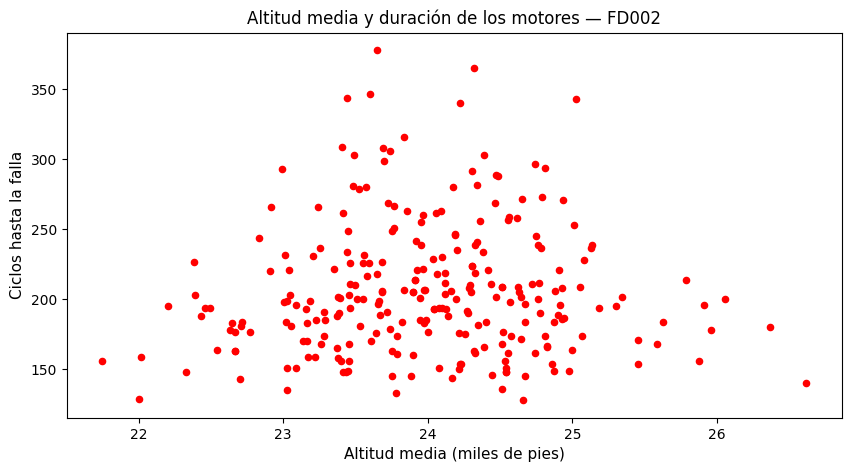

In [ ]:
altitud_prod_y_ciclos = pd.DataFrame()
altitud_prod_y_ciclos["promedio_altura"] = engine_altitud_change.groupby("motor_id")["configuracion_1"].mean()
altitud_prod_y_ciclos["ciclos"] = engine_altitud_change.groupby("motor_id")["ciclo"].max()

scatter_plot = altitud_prod_y_ciclos.plot.scatter(x = "promedio_altura", y = "ciclos", figsize=(10, 5), color = "red")
scatter_plot.set_title("Altitud media y duración de los motores — FD002")
scatter_plot.set_xlabel("Altitud media (miles de pies)", fontsize=11)
scatter_plot.set_ylabel("Ciclos hasta la falla", fontsize=11)


#Los motores de mayor duración presentan una altitud media cercana a 24, mientras que los promedios extremos corresponden a motores de menor duración.
#Sin embargo, esto podría deberse a que promediar más ciclos reduce las diferencias entre medias, y no necesariamente a un efecto de la altitud sobre la vida útil

#Los motores que operan bajo condiciones variables presentan una menor cantidad de ciclos hasta la falla que los que operan únicamente a nivel del mar

Text(0, 0.5, 'Ciclos hasta la falla')

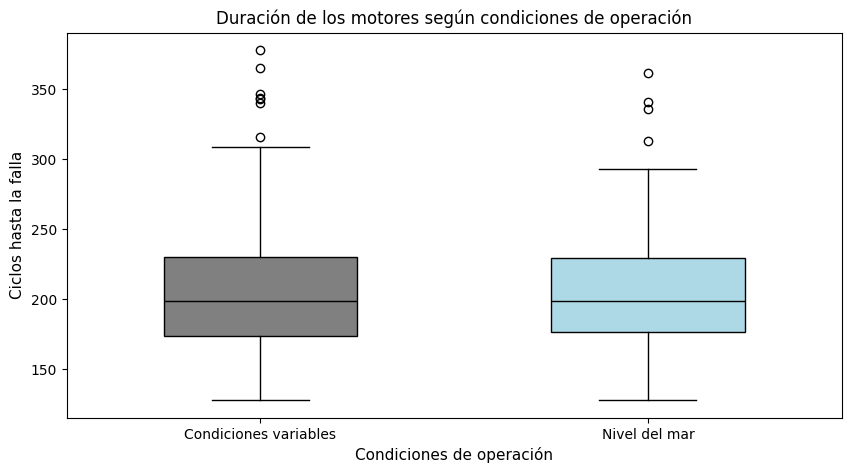

In [ ]:
df_comparacion = pd.DataFrame()

df_comparacion["Condiciones variables"] =  engine_altitud_change.groupby("motor_id")["ciclo"].max()

df_comparacion["Nivel del mar"] =  engine_data.groupby("motor_id")["ciclo"].max()

plot, box = df_comparacion.boxplot(figsize=(10, 5), widths=0.5, grid=False, color = "black", patch_artist=True, return_type='both')
box['boxes'][0].set_facecolor('grey')
box['boxes'][1].set_facecolor('lightblue')

plot.set_title("Duración de los motores según condiciones de operación")
plot.set_xlabel("Condiciones de operación", fontsize=11)
plot.set_ylabel("Ciclos hasta la falla", fontsize=11)


# Visualmente no hay una diferencia significativa en la duración de los motores entre ambas condiciones de operación

#Los motores de corta y larga duración ya presentan diferencias en sus primeras mediciones sobre los sensores:
#T30: Total temperature at HPC outlet °R


Text(0, 0.5, 'T30 media de los primeros 25 ciclos (°R)')

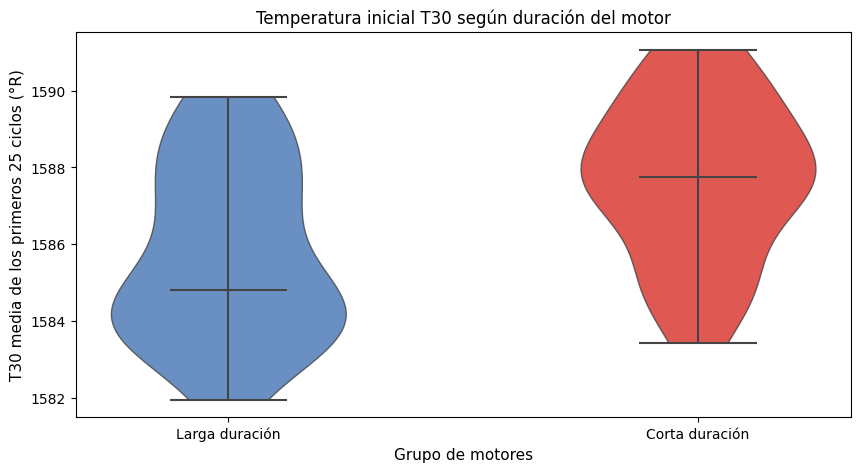

In [ ]:
#Usando:
#Data Set: FD001
#Train trjectories: 100
#Test trajectories: 100
#Conditions: ONE (Sea Level)
#Fault Modes: ONE (High-Pressure Compressor Degradation)

from pyspark.sql import *
from pyspark.sql.functions import *
from pyspark import SparkContext
from pyspark.sql import SQLContext

CANT_MOTORES = 25
CANT_CICLOS = 25

spark = SparkSession.builder.getOrCreate()
sc = spark.sparkContext

df_spark = spark.createDataFrame(engine_data)

rdd = df_spark.rdd

rdd = rdd.map(lambda x: (x.motor_id, (x.ciclo, x.T30)))

rdd_duracion = rdd.map(lambda x: (x[0], x[1][0]))
rdd_duracion = rdd_duracion.reduceByKey(lambda a, b: a if a > b else b)

longevo = rdd_duracion.takeOrdered(CANT_MOTORES, key=lambda x: -x[1])
menos_longevo = rdd_duracion.takeOrdered(CANT_MOTORES, key=lambda x: x[1])


for i, (motor_id, ciclo) in enumerate(longevo):
    longevo[i] = motor_id

for i, (motor_id, ciclo) in enumerate(menos_longevo):
    menos_longevo[i] = motor_id

motores_longevos = rdd.filter(lambda x: x[0] in longevo)
motores_menos_longevos = rdd.filter(lambda x: x[0] in menos_longevo)

primeros_ciclos_longevo = motores_longevos.filter(lambda x: x[1][0] <= CANT_CICLOS)
primeros_ciclos_menos_longevo = motores_menos_longevos.filter(lambda x: x[1][0] <= CANT_CICLOS)

primeros_ciclos_longevo = primeros_ciclos_longevo.map(lambda x: (x[0], (x[1][1], 1)))
primeros_ciclos_menos_longevo = primeros_ciclos_menos_longevo.map(lambda x: (x[0], (x[1][1], 1)))

promedio_longevo = primeros_ciclos_longevo.reduceByKey(lambda a,b: (a[0]+b[0], a[1]+b[1])).map(lambda x: (x[0],(x[1][0]/x[1][1])))
promedio_menos_longevo = primeros_ciclos_menos_longevo.reduceByKey(lambda a,b: (a[0]+b[0], a[1]+b[1])).map(lambda x: (x[0],(x[1][0]/x[1][1])))

promedio_longevo = promedio_longevo.map(lambda x: x[1])
promedio_menos_longevo = promedio_menos_longevo.map(lambda x: x[1])

valores_longevos = promedio_longevo.collect()
valores_menos_longevos = promedio_menos_longevo.collect()

plt.figure(figsize=(10, 5))

violines = plt.violinplot(
    [valores_longevos, valores_menos_longevos],
    showmedians=True
)

for violin, color in zip(violines["bodies"], ["#4575B4", "#D73027"]):
    violin.set_facecolor(color)
    violin.set_edgecolor("#444444")
    violin.set_alpha(0.8)

for parte in ["cmedians", "cbars", "cmins", "cmaxes"]:
    violines[parte].set_color("#444444")

plt.xticks([1, 2], ["Larga duración", "Corta duración"])
plt.title("Temperatura inicial T30 según duración del motor")
plt.xlabel("Grupo de motores", fontsize=11)
plt.ylabel(
    f"T30 media de los primeros {CANT_CICLOS} ciclos (°R)",
    fontsize=11
)

#En los motores seleccionados, el grupo de corta duración presenta temperaturas medias T30 más altas durante los primeros 25 ciclos.
#Esto sugiere una asociación entre la temperatura inicial y la duración posterior.